---
title: "Homework Answers Kaggle Competition: Predicting Irrigation Need"
author: Karisa Kopecek
date: today
format:
  html:
    embed-resources: true
    echo: true
---

## 4. Find and upvote 3-4 notebooks or discussion posts that you find particularly insightful or you could realistically apply in your own modeling. Provide the URLs in your Homework document. Posting on discussion boards in Kaggle is a great way to get some exposure, but is not required.

In Kaggle competition under discussion, scrolled through and found these and upvoted:

https://www.kaggle.com/competitions/playground-series-s6e4/discussion/688226   : The huge improvement shows that fixing class imbalance can matter way more than any fancy modeling and neural networks etc, which is something easy to overlook. The author's correction is also a good reminder to actually continue to keep testing improvements as we talked about in class that you can sometimes just get lucky splits (she isn't doing randomn forest based on her comment but same kind of luckiness can happen). I will make sure to first focus on getting a good baseline model that deals with class imbalance well and then add more complex stuff later.


https://www.kaggle.com/competitions/playground-series-s6e4/discussion/687167  : I hadn't heard of the Kruskal-Wallis test before seeing this post, but after googling it looks like it's a way to check which numeric features have the most different distributions across your target classes, helping you figure out what's actually worth paying attention to before you even start modeling. It's a simple pre modeling step that gives you a ranked list of features based on how well they separate your groups. The plots this author made show soil moisture and rainfall both drop clearly as irrigation need goes up while temperature rises, which makes intuitive sense and shows the top features are doing real work in separating the classes. I could realistically use this in my own work to quickly narrow down which features deserve attention, and add on my own initial data visualization ideas to go more in depth if I see any more patterns that would help my later modeling. 

In Kaggle competition under code, found this public code file: 

https://www.kaggle.com/code/jayhawk1900/lgb-catboost-ensemble : 

This notebook trains both "LightGBM" and "CatBoost" using 5-fold cross validation, then blends their predictions 50/50 to get a final submission. CatBoost hits about 0.9657 balanced accuracy on its own. Something we touched on in class and which is represented here is that CatBoost can handle categorical columns without needing to encode them first, so the author keeps two versions of the data, one encoded for LightGBM and one left as-is for CatBoost (we touched breifly on CatBoost but I did have to google more as this code seems very advanced). I find the ensembling approach really applicable because averaging two models' predictions is something I could realistically add to my own pipeline without overcomplicating things. Also just seeing the CatBoost setup here gives me a good starting point since I haven't used it much before.

https://www.kaggle.com/code/jaspreetsingh9652/optuna-with-xgboost#Ploting-Optuna : 

The author let Optuna tune hyperparameters on an already trimmed down set of 14 features rather than the full dataset, which makes the search faster and more focused. He also fed the best params directly into XGBoost with `**study.best_params` which I will probably use on my own code at some point (since it skips having to manually copy over every parameter after tuning). 

## 5 Create an EDA notebook for the competition. Do your initial EDA in that notebook and provide the URL in your Homework document. What insights did you gain? Is there a feature you think is especially important? Any potential issues? Did you try anything new that you learned from Kaggle or other sources? Consider posting a public EDA notebook on Kaggle.

EDA Notbook Link with just code (explanation of findings below): https://github.com/karisamarykopecek/Kaggle_Comp_Irrigation/blob/main/EDA_Kopecek_Irrigation.ipynb

### Insights

| # | Finding | Detail |
|---|---|---|
| 1 | **Strong class imbalance** | High = 3.3% (21K), Medium = 37.9%, Low = 58.7%. Accuracy would be a misleading metric given this imbalance. Need to handle this in ML model somehow |
| 2 | **No missing values** | 630K rows completely clean! yay |
| 3 | **No feature correlations** | Max pairwise r = 0.04. Features are independent, yay |
| 4 | **Symmetric distributions** | Looking at sweetviz, skew is almost 0 for all of them (numeric), (categorial) has even spread across categories except for crop type |
| 5 | **No train/test shift** | Train and test have same distribution, no difference really |

### Feature Importance Ranking (just based on my plots and what I visually see)
### classes being more separated tell me they may potentially be good predictors

| Rank | Feature | Type | Signal | Reasoning |
|---|---|---|---|---|
| 1 | `crop growth stage` | categorial | high | different irrigation needed for diff stage |
| 2 | `mulching used` | categorical | high | different mulch, different irrigation need |
| 3 | `Soil_Moisture` | Numeric | Medium | Lower moisture, Higher need |
| 4 | `Temperature_C` | Numeric | Med | Higher temp, Higher need |
| 5 | `Wind_Speed_kmh` | Numeric | Low | Higher wind, Higher need |
| 6 | `Rainfall_mm` | Numeric | Low | Lower rain, Higher need |

### Potential Issues for Modeling

1. **Class imbalance**
2. Simple models may match complex ones, given the data is so clean and symmetric
3. **Low correlation** Most features have r < 0.10 with target. Feature engineering may help.

### Hypotheses for Modeling

1. A tree-based model might be a good starting point
2. maybe need to engineer feature for `Crop_Growth_Stage or Mulching_Used` or maybe include raindfall? will have to experiment to see if any feature engineering helps model
3. `Previous_Irrigation_mm`, `Organic_Carbon`, `Sunlight_Hours`, `Field_Area_hectare` don't seem really useful thusfar

### something new I tried and LOVED:
I learned to look at class separation as a potential flag for if the feature will be important later! Learned this from a discussion post and LOVED the idea, find it very useful. May not work in practice, I will have to see, but could be used somewhere else someday in my career. 

## 6 Use two distinct modeling approaches, one bagging and one boosting. You may build other models, but the goal for the homework is to compare bagging and boosting approaches. You must submit at least one boosting and one bagging set of predictions to Kaggle (gets your submission workflow established). Consider exploring models we didn't cover in class. Make sure you are using cross-validation or another validation metric to improve your modeling. Do some tuning but don't spend hours and hours on it at this stage. Again, consider posting a public notebook on Kaggle (many people post only one or two notebooks out of many that they create).

Bagging model Link: https://github.com/karisamarykopecek/Kaggle_Comp_Irrigation/blob/main/bagging_models.ipynb

Boosting Model Link: https://github.com/karisamarykopecek/Kaggle_Comp_Irrigation/blob/main/boosting_models.ipynb

## What did you try?

Six models were tested across bagging and boosting using weighted F1. I chose that metric because of the High class imbalance (3.3% of data). For bagging, BaggingClassifier, Random Forest, and Extra Trees were all run with class_weight='balanced' to prevent the majority classes from drowning out the minority High class. For boosting, AdaBoost used shallow decision trees as weak learners, while XGBoost and LightGBM were tuned with Optuna across 20 trials each. Three engineered features were added across both notebooks: a crop stage and mulching interaction term, a physical stress index, and a water deficit proxy. All engineered features were motivated by EDA findings (see above). I wanted to try to just test a variety of things and kind of randomly picked numbers in some cases for tuning, also looked at the discussions and other stuff on Kaggle to see numbers other people commonly use for things. I tried a variety of different numbers for hyperparameters like depth, learning rate, and subsampling, and ended up deleting and re-running code a bunch of times in some cases.


## What worked well?

Random Forest, XGBoost, and LightGBM all performed well, with CV weighted F1 scores of 0.9808, 0.9823, and 0.9817 respectively. Random Forest has feature randomness at each split and improved the model a lot compared to plain BaggingClassifier (0.9799). XGBoost and LightGBM both improved further with Optuna tuning, which searched over depth, learning rate, subsampling, and regularization parameters. I am really liking using Optuna tuning as I hadn't used it before this class and it has been consistently performing very well for me. I also was able to feature engineer some really good features based on my EDA and for every model those engineered features worked a LOT better than individual categories. I may want to continue to add more engineered features since they did so well. More complex models are doing better (which is to be expected) and I think as we go on my limit will be due to time as some models take a long time to run. Since this isn't a real giant supercomputer operation, I don't really have to worry too much about operational cost though.


## What didn't work well?

Extra Trees and AdaBoost were the weakest models, scoring 0.9465 and 0.9732 respectively. Extra Trees uses random split thresholds rather than finding the optimal split at each node, which is designed to reduce overfitting on noisy data but this data was very structured so overall it wasn't a good choice but I wanted to see what would happen. AdaBoost struggled to capture the complex interaction between Crop Growth Stage and Mulching like some of the other models, likely because shallow trees as weak learners can't model that kind of multi-feature boundary well. Overall, the much simpler models really struggled which I was disappointed by.


## Were model improvements meaningful or small? How did boosting vs. bagging compare for your work?

The improvements between the top three models (Random Forest at 0.9808, XGBoost at 0.9823, and LightGBM at 0.9817) were small, all within 0.002 F1. I struggled because the dataset was so clean which kind of limited the improvement I was seeing weirdly. The bigger and more meaningful jump was on the leaderboard between the bagging and boosting submissions, which differed by 0.011. Part of that gap is also explained by LightGBM training on the full 630K rows while the Random Forest submission was capped at 200K due to memory constraints (my models just ran forever and wouldn't load... maybe need to look into this for next time). The simpler models also had bigger gaps, with Extra Trees at 0.9465 and AdaBoost at 0.9732 falling well behind the top three.

## Table

| Model | Family | CV Weighted F1 | Leaderboard |
|---|---|---|---|
| Extra Trees | Bagging | 0.9465 (sd 0.0007) | - |
| AdaBoost | Boosting | 0.9732 (sd 0.0024) | - |
| BaggingClassifier | Bagging | 0.9799 (sd 0.0005) | - |
| Random Forest | Bagging | 0.9808 (sd 0.0008) | 0.95322 |
| LightGBM | Boosting | 0.9817 (sd 0.0006) | - |
| XGBoost | Boosting | 0.9823 (sd 0.0004) | 0.96382 |

## Overall leaderboard position: 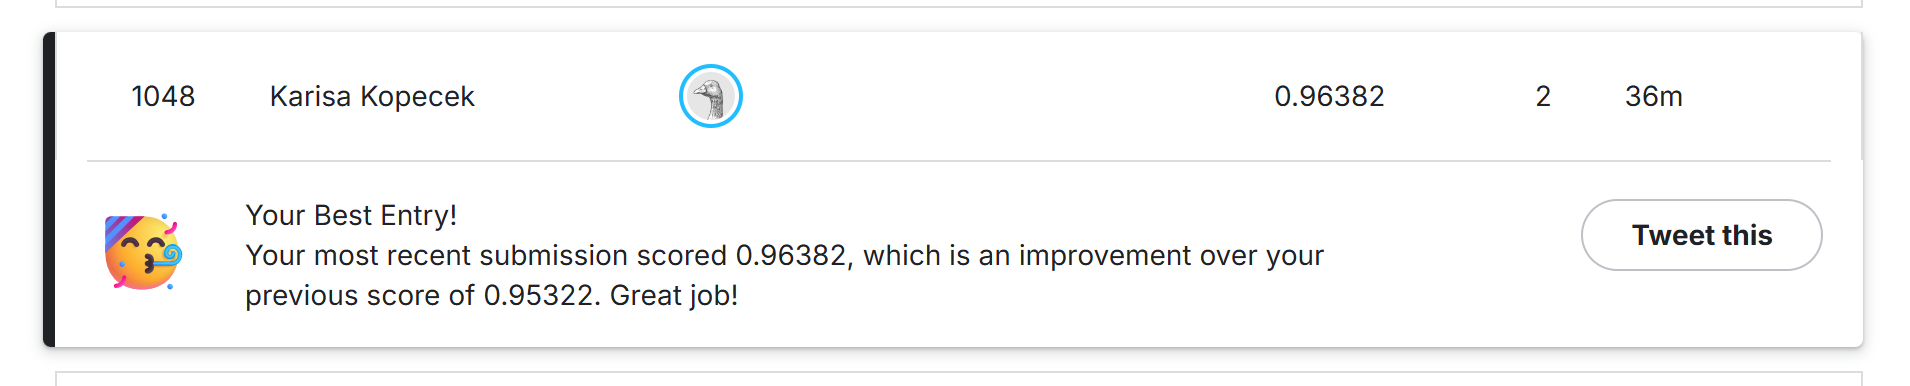

## What is your "phase 2" plan to improve your model performance? Note that although the leaderboard is fun to watch, you are not graded on it (and a shake up often occurs at the end!)


My main plan is to continue feature engineering since that made the biggest difference so far. I want to try more interaction terms between the categorical features since stage_mulch worked so well, and maybe explore some ratio features between the numeric columns. I also want to try stacking or blending the top models together since Random Forest, XGBoost, and LightGBM all performed similarly and combining them might squeeze out a bit more performance. I also want to try training on the full dataset for all models since LightGBM clearly benefited from that and I think Random Forest was held back by the 200K cap.